<a href="https://colab.research.google.com/github/Fatimatari123/MorphoCal-Research-paper-framework/blob/main/Morphocal_Depondfi'24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mounting the drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir('/content/drive/MyDrive/')

['Lab 02',
 'Classroom',
 'Fatima CV.pdf',
 'fsc_1.jpg',
 'domicile_1.jpg',
 'Fatima CV (1) (1).pdf',
 'Fatima CV (1).pdf',
 'MorphoCal: a multi-stage deep learning framework for fish length estimation in challenging underwater pond environments',
 'cover letter.pdf',
 'Colab Notebooks',
 'DeepFish_data',
 'Final Submission']

# Installing dependencies and also Ultralytics for YOLO

In [1]:
!pip install -U ultralytics opencv-python-headless numpy matplotlib

In [2]:
import os
import cv2
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import shutil
from shutil import copyfile
import matplotlib.pyplot as plt
from matplotlib import animation, rc
rc('animation', html='jshtml')
from PIL import Image
import ultralytics
from ultralytics import YOLO
ultralytics.checks()

Ultralytics 8.4.131 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


**Loading file content**:To check what new directories need to be created for starting the process

In [3]:
import os

# Update this path if your folder shortcut name is slightly different
drive_folder = "/content/drive/MyDrive/Final Submission"

if os.path.exists(drive_folder):
    print("Found files in Drive:")
    print(os.listdir(drive_folder))
else:
    print("Folder path not found. Available folders in MyDrive:")
    print(os.listdir("/content/drive/MyDrive/"))

Found files in Drive:
['best.pt', "DepondFi'24.ipynb", 'Testing', 'Video Test', 'Visual Results', 'Training', 'Predicted_Keypoints']


# Extracting the Best.pt file

In [4]:
import gdown

# Extracting the file ID from your link
file_id = "1mJwWSaC_GUxin7HI62TcKjgXvZCM18GF"
url = f"https://drive.google.com/uc?id={file_id}"

# Choose your output filename (e.g., 'best_updated.pt' if it's your model weights)
output = "best_updated.pt"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1mJwWSaC_GUxin7HI62TcKjgXvZCM18GF
From (redirected): https://drive.google.com/uc?id=1mJwWSaC_GUxin7HI62TcKjgXvZCM18GF&confirm=t&uuid=38598dee-8146-4dd7-b82f-bfafa7e39fd8
To: /content/best_updated.pt
100%|██████████| 137M/137M [00:04<00:00, 31.9MB/s]


'best_updated.pt'

# **Running Inference on Existing Pre trained Model using YOLOv26 Pose**

In [7]:
import os
import glob
from ultralytics import YOLO

# 1. Load the model weights
model_path = "/content/best_updated.pt"
if not os.path.exists(model_path):
    matches = glob.glob("/content/**/best_updated.pt", recursive=True)
    if matches: model_path = matches[0]

model = YOLO(model_path)

# 2. Automatically locate the test images folder in Colab/Drive
test_dir_candidates = [
    "/content/dataset/images/test",
    "/content/drive/MyDrive/Final Submission/Testing",
    "/content/drive/MyDrive/Final Submission/Training"
]

test_source = None
for candidate in test_dir_candidates:
    if os.path.exists(candidate):
        test_source = candidate
        break

# Fallback: search for any folder named 'test' or 'Testing'
if test_source is None:
    found_dirs = glob.glob("/content/**/test", recursive=True) + glob.glob("/content/**/Testing", recursive=True)
    if found_dirs:
        test_source = found_dirs[0]

if test_source is None:
    raise FileNotFoundError("Could not find your test images directory. Please check your Google Drive mount or folder structure.")

print(f" Found test image directory at: {test_source}")

# 3. Run batch prediction successfully
results = model.predict(
    source=test_source,
    save=True,
    save_txt=True,
    conf=0.4,
    batch=16        # Processes 16 images at a time to maximize GPU parallelism
)

print("Inference completed successfully!")

✅ Found test image directory at: /content/drive/MyDrive/Final Submission/Testing

image 1/120 /content/drive/MyDrive/Final Submission/Testing/Screenshot-2024-04-22-201557_png_jpg.rf.8f2a4c9843a8da708afbf0c62a3eede6.jpg: 640x640 2 Mouths, 2 Eyes, 1 Fish center, 3 Bottom centers, 1 start point tail, 2 top outline tails, 2 mid outline tails, 50.1ms
image 2/120 /content/drive/MyDrive/Final Submission/Testing/Screenshot-2024-04-22-202611_png_jpg.rf.e57ebce5044a9f0661acc240af6a23a0.jpg: 640x640 2 Mouths, 3 Eyes, 3 Top fins, 1 Bottom center, 4 start point tails, 2 top outline tails, 1 mid outline tail, 3 bottom outline tails, 50.1ms
image 3/120 /content/drive/MyDrive/Final Submission/Testing/Screenshot-2024-04-22-204332_png_jpg.rf.541df94b1a1bf0a54830577364efd30b.jpg: 640x640 3 Mouths, 2 Eyes, 3 Top fins, 1 Fish center, 1 Bottom center, 2 start point tails, 3 top outline tails, 1 mid outline tail, 1 bottom outline tail, 50.1ms
image 4/120 /content/drive/MyDrive/Final Submission/Testing/Screen

# **Parsing Landmarks & Calculating Pixel Lengths**

In [9]:
import os
import glob
import numpy as np
import pandas as pd

label_dir = "/content/runs/detect/predict/labels"
label_files = glob.glob(os.path.join(label_dir, "*.txt"))

IMG_WIDTH = 640
IMG_HEIGHT = 640

MOUTH_CLASS_ID = 0
TAIL_CLASS_ID = 5

# Define strict biological pixel length limits for your fish setup
# Adjust these bounds based on how large the fish appear in your 640x640 frames
MIN_FISH_LENGTH_PX = 40.0
MAX_FISH_LENGTH_PX = 450.0

results = []
multi_fish_frame_count = 0

for file_path in label_files:
    filename = os.path.basename(file_path)

    with open(file_path, "r") as f:
        lines = f.readlines()

    mouths = []
    tails = []

    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            cls_id = int(parts[0])
            x_center = float(parts[1]) * IMG_WIDTH
            y_center = float(parts[2]) * IMG_HEIGHT

            if cls_id == MOUTH_CLASS_ID:
                mouths.append((x_center, y_center))
            elif cls_id == TAIL_CLASS_ID:
                tails.append((x_center, y_center))

    if len(mouths) > 1 or len(tails) > 1:
        multi_fish_frame_count += 1

    # Safe Multi-Fish Pairing Logic
    if mouths and tails:
        matched_tails = set()  # Track tails so a single tail isn't double-assigned

        for m_x, m_y in mouths:
            valid_candidates = []

            for t_x, t_y in tails:
                if (t_x, t_y) in matched_tails:
                    continue

                dist = np.sqrt((t_x - m_x)**2 + (t_y - m_y)**2)

                # Check if the distance falls within realistic fish dimensions
                if MIN_FISH_LENGTH_PX <= dist <= MAX_FISH_LENGTH_PX:
                    valid_candidates.append(((t_x, t_y), dist))

            # If we found valid tail candidates for this mouth, pick the closest one
            if valid_candidates:
                # Sort by distance to find the true pair for this specific fish
                valid_candidates.sort(key=lambda x: x[1])
                best_tail, pixel_length = valid_candidates[0]

                matched_tails.add(best_tail)

                results.append({
                    "image": filename,
                    "mouth": (m_x, m_y),
                    "tail": best_tail,
                    "pixel_length": pixel_length
                })

# Convert to DataFrame & Apply Calibration Factor
df = pd.DataFrame(results)
PIXELS_PER_CM = 50.0  # Replace with your actual calibration scale factor
df['length_cm'] = df['pixel_length'] / PIXELS_PER_CM

output_csv = "/content/fish_lengths_multifish_verified.csv"
df.to_csv(output_csv, index=False)

print(f"Processed frames with multiple fish: {multi_fish_frame_count}")
print(f"Successfully extracted {len(results)} verified individual fish measurements.")
print(f"Results saved to {output_csv}")

Processed frames with multiple fish: 101
Successfully extracted 199 verified individual fish measurements.
Results saved to /content/fish_lengths_multifish_verified.csv


# **Ray-Plane Projection and Length measurement(Qualitative Analysis)**: Verifying models length prediction on a testing image

In [31]:
import numpy as np

# Your existing MorphoCal calibration
W_native = 4498.78
H_native = 3641.20

K_native = np.array([
    [4594.83, 0, 2249.39],
    [0, 4595.70, 1820.60],
    [0, 0, 1]
], dtype=np.float32)

dist_coeffs = np.array([
    -0.2738,
     0.4506,
    -4.21e-4,
     1.75e-3,
    -0.9164
], dtype=np.float32)

z_plane = 50.0

np.savez(
    "/content/calibration.npz",
    W_native=W_native,
    H_native=H_native,
    K_native=K_native,
    dist_coeffs=dist_coeffs,
    z_plane=z_plane
)

print("Calibration saved successfully.")

Calibration saved successfully.



Fish Association
Fish 1: Center(554.8,275.7) -> Mouth(516.5,236.0) -> Tail(604.5,359.3) | Pixels: 151.43
Fish 2: Center(559.1,285.8) -> Mouth(28.9,142.2) -> Tail(314.5,604.2) | Pixels: 543.17

Final Fish Length
Fish 1: 10.78 cm | Pixels: 151.43
Fish 2: 37.94 cm | Pixels: 543.17


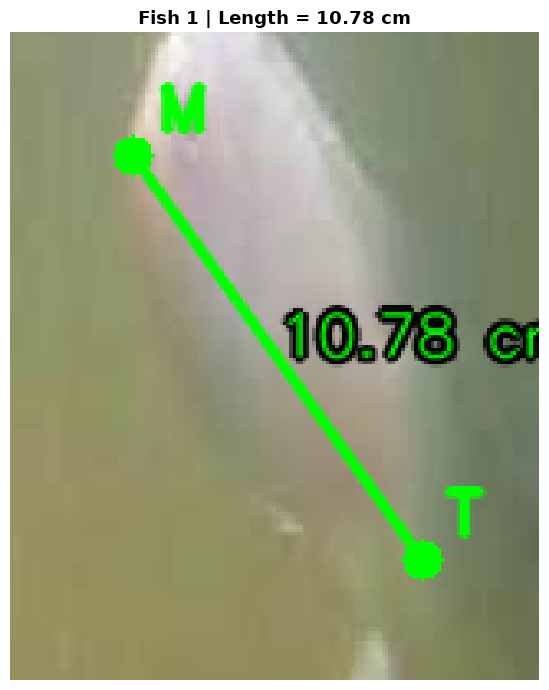

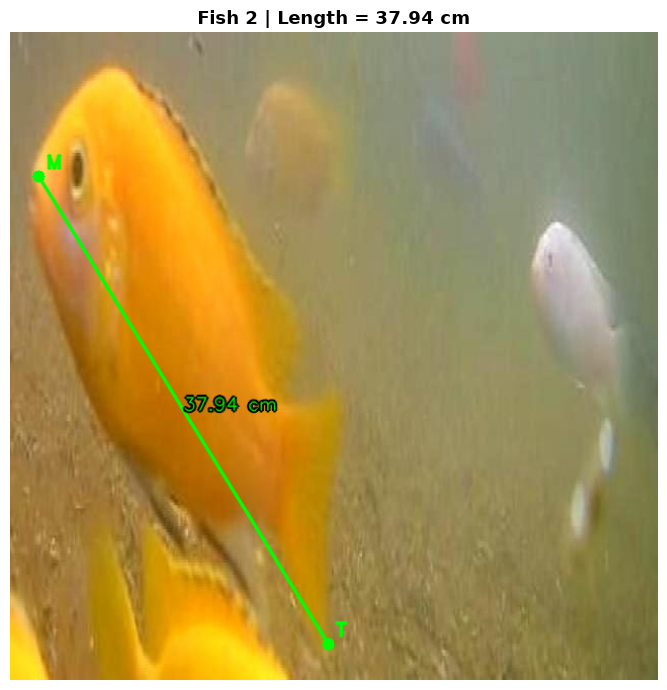


Saved:
/content/separate_fish/fish_measurements.csv


In [36]:

import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

MODEL_PATH = "/content/best_updated.pt"

IMAGE_NAME = (
    "frame2089_jpg.rf."
    "ea8cf839b24fb8f19d411e6b4581158d.jpg"
)

CALIBRATION_PATH = "/content/calibration.npz"

OUTPUT_DIR = "/content/separate_fish"

os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(MODEL_PATH):

    matches = glob.glob(
        "/content/**/best_updated.pt",
        recursive=True
    )

    if not matches:
        raise FileNotFoundError(
            "best_updated.pt was not found."
        )

    MODEL_PATH = matches[0]


model = YOLO(MODEL_PATH)


def normalize_name(name):
    return (
        str(name)
        .strip()
        .lower()
        .replace("_", " ")
        .replace("-", " ")
    )


def find_class(target_name):

    target_name = normalize_name(
        target_name
    )

    for class_id, class_name in model.names.items():

        if normalize_name(
            class_name
        ) == target_name:

            return class_id

    return None


MOUTH_CLASS = find_class("Mouth")

CENTER_CLASS = find_class("Fish center")

BOTTOM_TAIL_CLASS = find_class(
    "Bottom outline tail"
)


if MOUTH_CLASS is None:
    raise ValueError(
        "Mouth class was not found."
    )

if CENTER_CLASS is None:
    raise ValueError(
        "Fish center class was not found."
    )

if BOTTOM_TAIL_CLASS is None:
    raise ValueError(
        "Bottom outline tail class was not found."
    )


image_matches = glob.glob(
    f"/content/**/{IMAGE_NAME}",
    recursive=True
)

if not image_matches:
    raise FileNotFoundError(
        f"Could not find image:\n{IMAGE_NAME}"
    )


IMAGE_PATH = image_matches[0]


image = cv2.imread(
    IMAGE_PATH
)

if image is None:
    raise ValueError(
        "Could not read the image."
    )


IMAGE_HEIGHT, IMAGE_WIDTH = (
    image.shape[:2]
)

if not os.path.exists(
    CALIBRATION_PATH
):

    raise FileNotFoundError(
        "\ncalibration.npz was not found.\n"
        "Create the calibration file before running "
        "centimeter measurements."
    )


calibration = np.load(
    CALIBRATION_PATH
)


W_NATIVE = float(
    calibration["W_native"]
)

H_NATIVE = float(
    calibration["H_native"]
)

K_NATIVE = calibration[
    "K_native"
].astype(np.float32)

DIST_COEFFS = calibration[
    "dist_coeffs"
].astype(np.float32)

Z_PLANE = float(
    calibration["z_plane"]
)


def pixel_to_3d(point):

    x = float(point[0])
    y = float(point[1])


    native_x = (
        x *
        W_NATIVE /
        IMAGE_WIDTH
    )

    native_y = (
        y *
        H_NATIVE /
        IMAGE_HEIGHT
    )


    pixel = np.array(
        [[[native_x, native_y]]],
        dtype=np.float32
    )


    undistorted = cv2.undistortPoints(
        pixel,
        K_NATIVE,
        DIST_COEFFS
    )


    nx = float(
        undistorted[0, 0, 0]
    )

    ny = float(
        undistorted[0, 0, 1]
    )


    ray = np.array(
        [
            nx,
            ny,
            1.0
        ],
        dtype=np.float64
    )


    return ray * (
        Z_PLANE /
        ray[2]
    )


results = model.predict(
    source=IMAGE_PATH,
    conf=0.25,
    verbose=False
)


boxes = results[0].boxes


mouths = []
centers = []
bottom_tails = []


for box in boxes:

    class_id = int(
        box.cls[0]
    )

    confidence = float(
        box.conf[0]
    )


    x1, y1, x2, y2 = (
        box.xyxy[0]
        .cpu()
        .numpy()
    )


    cx = (
        x1 + x2
    ) / 2.0

    cy = (
        y1 + y2
    ) / 2.0


    detection = {

        "point": np.array(
            [cx, cy],
            dtype=np.float64
        ),

        "confidence":
            confidence

    }


    if class_id == MOUTH_CLASS:

        mouths.append(
            detection
        )

    elif class_id == CENTER_CLASS:

        centers.append(
            detection
        )

    elif class_id == BOTTOM_TAIL_CLASS:

        bottom_tails.append(
            detection
        )


if not centers:
    raise ValueError(
        "No fish centers were detected."
    )

if not mouths:
    raise ValueError(
        "No mouths were detected."
    )

if not bottom_tails:
    raise ValueError(
        "No bottom tail points were detected."
    )

centers.sort(
    key=lambda item:
    item["point"][0]
)

remaining_mouths = mouths.copy()

remaining_tails = bottom_tails.copy()

fish_data = []


for center in centers:

    center_point = center[
        "point"
    ]

    if not remaining_mouths:
        break


    mouth_index = min(
        range(
            len(
                remaining_mouths
            )
        ),
        key=lambda i:
        np.linalg.norm(
            center_point
            -
            remaining_mouths[i][
                "point"
            ]
        )
    )


    selected_mouth = (
        remaining_mouths.pop(
            mouth_index
        )
    )

    if not remaining_tails:
        break


    tail_index = min(
        range(
            len(
                remaining_tails
            )
        ),
        key=lambda i:
        np.linalg.norm(
            center_point
            -
            remaining_tails[i][
                "point"
            ]
        )
    )


    selected_tail = (
        remaining_tails.pop(
            tail_index
        )
    )


    fish_data.append({

        "center":
            center,

        "mouth":
            selected_mouth,

        "bottom_tail":
            selected_tail

    })

print("\nFish Association")
print("=" * 35)


for fish_id, fish in enumerate(
    fish_data,
    start=1
):

    center = fish[
        "center"
    ]["point"]

    mouth = fish[
        "mouth"
    ]["point"]

    tail = fish[
        "bottom_tail"
    ]["point"]


    pixel_length = np.linalg.norm(
        tail - mouth
    )


    print(
        f"Fish {fish_id}: "
        f"Center({center[0]:.1f},{center[1]:.1f}) "
        f"-> Mouth({mouth[0]:.1f},{mouth[1]:.1f}) "
        f"-> Tail({tail[0]:.1f},{tail[1]:.1f}) "
        f"| Pixels: {pixel_length:.2f}"
    )


measurements = []


for fish_id, fish in enumerate(
    fish_data,
    start=1
):

    mouth = fish[
        "mouth"
    ]["point"]

    bottom_tail = fish[
        "bottom_tail"
    ]["point"]


    pixel_length = np.linalg.norm(
        bottom_tail - mouth
    )


    mouth_3d = pixel_to_3d(
        mouth
    )

    tail_3d = pixel_to_3d(
        bottom_tail
    )

    length_cm = np.linalg.norm(
        tail_3d - mouth_3d
    )


    measurements.append({

        "Fish":
            fish_id,

        "Mouth_X":
            mouth[0],

        "Mouth_Y":
            mouth[1],

        "Bottom_Tail_X":
            bottom_tail[0],

        "Bottom_Tail_Y":
            bottom_tail[1],

        "Pixel_Length":
            pixel_length,

        "Length_cm":
            length_cm,

        "Mouth_Confidence":
            fish["mouth"][
                "confidence"
            ],

        "Tail_Confidence":
            fish["bottom_tail"][
                "confidence"
            ]

    })


results_df = pd.DataFrame(
    measurements
)


print("\nFinal Fish Length")
print("=" * 35)


for _, row in results_df.iterrows():

    print(
        f"Fish {int(row['Fish'])}: "
        f"{row['Length_cm']:.2f} cm "
        f"| Pixels: "
        f"{row['Pixel_Length']:.2f}"
    )

for fish_id, fish in enumerate(
    fish_data,
    start=1
):

    center = fish[
        "center"
    ]["point"]

    mouth = fish[
        "mouth"
    ]["point"]

    tail = fish[
        "bottom_tail"
    ]["point"]


    length_cm = measurements[
        fish_id - 1
    ]["Length_cm"]

    fish_points = np.array([
        center,
        mouth,
        tail
    ])


    min_x = np.min(
        fish_points[:, 0]
    )

    max_x = np.max(
        fish_points[:, 0]
    )

    min_y = np.min(
        fish_points[:, 1]
    )

    max_y = np.max(
        fish_points[:, 1]
    )


    fish_width = (
        max_x - min_x
    )

    fish_height = (
        max_y - min_y
    )


    padding = max(
        fish_width,
        fish_height,
        1
    ) * 0.30


    crop_x1 = max(
        0,
        int(min_x - padding)
    )

    crop_y1 = max(
        0,
        int(min_y - padding)
    )

    crop_x2 = min(
        IMAGE_WIDTH,
        int(max_x + padding)
    )

    crop_y2 = min(
        IMAGE_HEIGHT,
        int(max_y + padding)
    )


    fish_image = image[
        crop_y1:crop_y2,
        crop_x1:crop_x2
    ].copy()


    local_mouth = (
        int(mouth[0] - crop_x1),
        int(mouth[1] - crop_y1)
    )

    local_tail = (
        int(tail[0] - crop_x1),
        int(tail[1] - crop_y1)
    )


    cv2.line(
        fish_image,
        local_mouth,
        local_tail,
        (0, 255, 0),
        2,
        cv2.LINE_AA
    )

    cv2.circle(
        fish_image,
        local_mouth,
        6,
        (0, 255, 0),
        -1
    )


    cv2.circle(
        fish_image,
        local_tail,
        6,
        (0, 255, 0),
        -1
    )

    cv2.putText(
        fish_image,
        "M",
        (
            local_mouth[0] + 8,
            local_mouth[1] - 8
        ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2,
        cv2.LINE_AA
    )


    cv2.putText(
        fish_image,
        "T",
        (
            local_tail[0] + 8,
            local_tail[1] - 8
        ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2,
        cv2.LINE_AA
    )


    mid_x = int(
        (
            local_mouth[0]
            +
            local_tail[0]
        ) / 2
    )

    mid_y = int(
        (
            local_mouth[1]
            +
            local_tail[1]
        ) / 2
    )


    label = (
        f"{length_cm:.2f} cm"
    )


    # Black outline
    cv2.putText(
        fish_image,
        label,
        (
            mid_x,
            mid_y
        ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 0),
        3,
        cv2.LINE_AA
    )


    # Green text
    cv2.putText(
        fish_image,
        label,
        (
            mid_x,
            mid_y
        ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )


    output_path = os.path.join(
        OUTPUT_DIR,
        f"fish_{fish_id}_measurement.jpg"
    )


    cv2.imwrite(
        output_path,
        fish_image
    )

    plt.figure(
        figsize=(7, 7)
    )

    plt.imshow(
        cv2.cvtColor(
            fish_image,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        f"Fish {fish_id} | "
        f"Length = {length_cm:.2f} cm",
        fontsize=13,
        fontweight="bold"
    )

    plt.axis("off")

    plt.tight_layout()

    plt.show()
output_csv = os.path.join(
    OUTPUT_DIR,
    "fish_measurements.csv"
)
results_df.to_csv(
    output_csv,
    index=False
)
print("\nSaved:")
print(output_csv)

# **Statistical Avaluation**: without Ground truth values

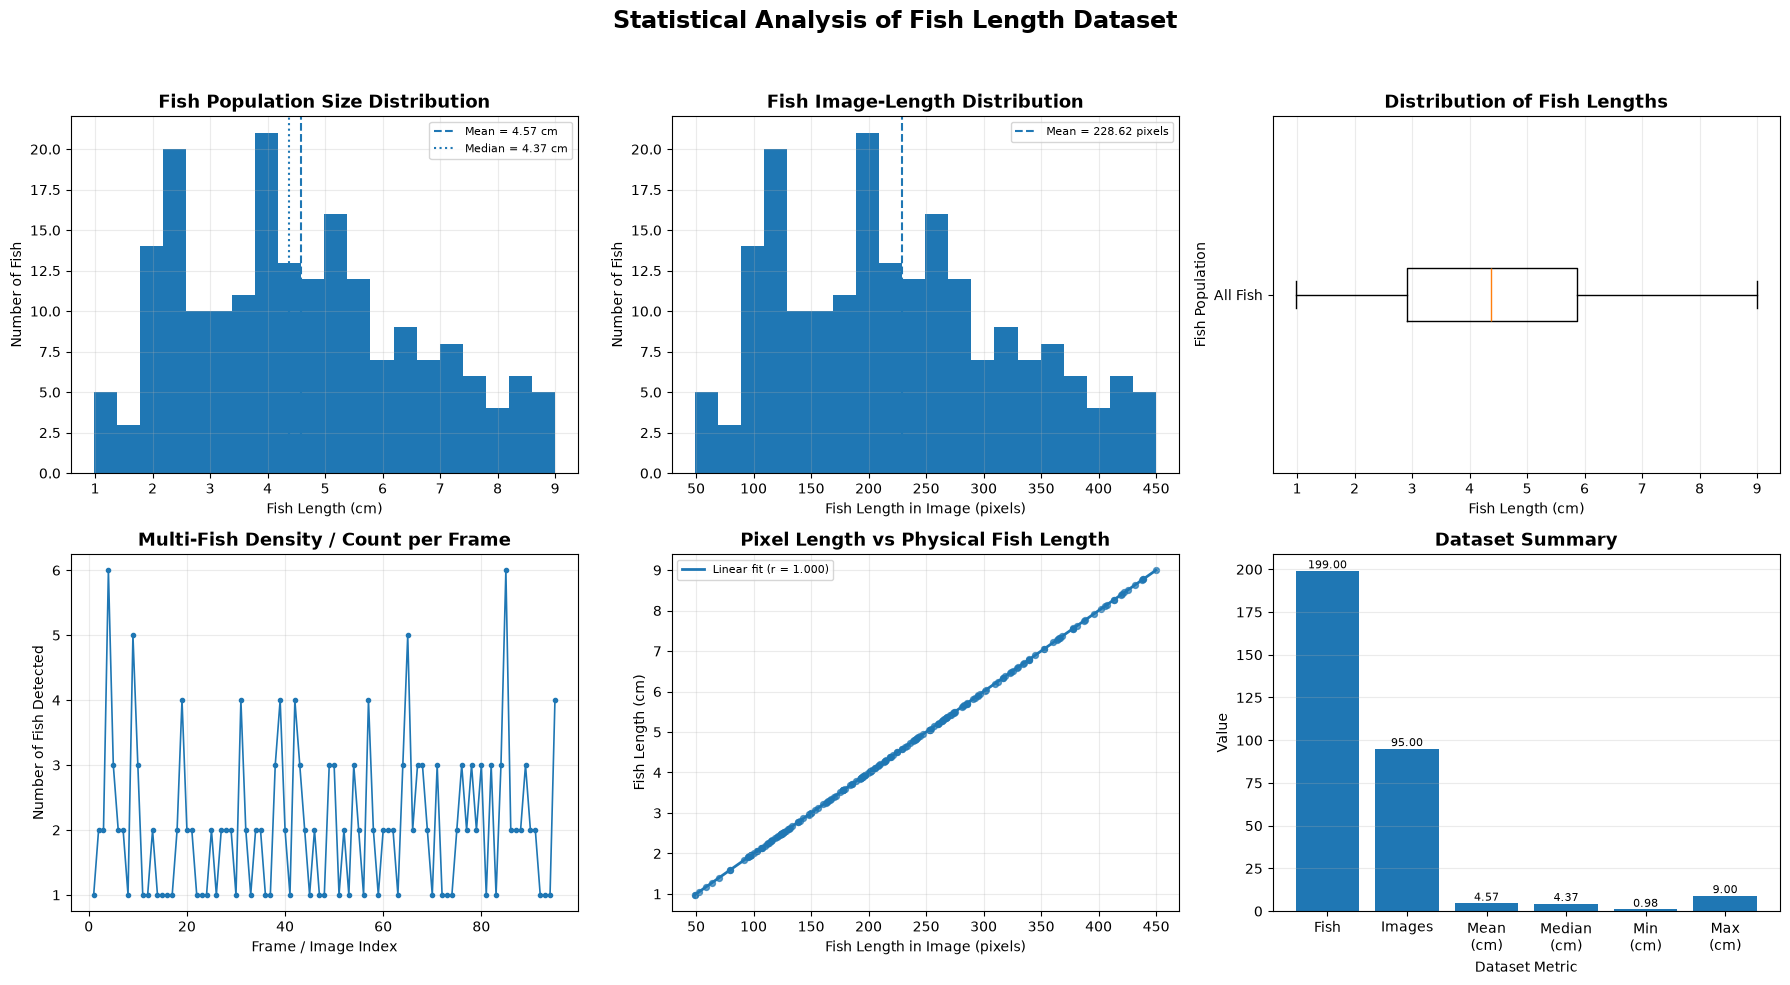

In [46]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


csv_path = "/content/fish_lengths_multifish_verified.csv"

df = pd.read_csv(csv_path)

df["pixel_length"] = pd.to_numeric(
    df["pixel_length"],
    errors="coerce"
)

df["length_cm"] = pd.to_numeric(
    df["length_cm"],
    errors="coerce"
)

df = df.dropna(
    subset=[
        "pixel_length",
        "length_cm"
    ]
).copy()


lengths = df["length_cm"].to_numpy()
pixel_lengths = df["pixel_length"].to_numpy()

fish_count = (
    df.groupby("image")
    .size()
)

frame_index = np.arange(
    1,
    len(fish_count) + 1
)

counts = fish_count.to_numpy()

mean_length = np.mean(lengths)
median_length = np.median(lengths)

mean_pixel_length = np.mean(
    pixel_lengths
)

slope, intercept = np.polyfit(
    pixel_lengths,
    lengths,
    1
)

x_fit = np.linspace(
    pixel_lengths.min(),
    pixel_lengths.max(),
    200
)

y_fit = (
    slope * x_fit
    + intercept
)

correlation = np.corrcoef(
    pixel_lengths,
    lengths
)[0, 1]


fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

ax = axes[0, 0]

ax.hist(
    lengths,
    bins=20
)

ax.axvline(
    mean_length,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {mean_length:.2f} cm"
)

ax.axvline(
    median_length,
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {median_length:.2f} cm"
)

ax.set_title(
    "Fish Population Size Distribution",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel(
    "Fish Length (cm)"
)

ax.set_ylabel(
    "Number of Fish"
)

ax.legend(
    fontsize=8
)

ax.grid(
    alpha=0.25
)

ax = axes[0, 1]

ax.hist(
    pixel_lengths,
    bins=20
)

ax.axvline(
    mean_pixel_length,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Mean = "
        f"{mean_pixel_length:.2f} pixels"
    )
)

ax.set_title(
    "Fish Image-Length Distribution",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel(
    "Fish Length in Image (pixels)"
)

ax.set_ylabel(
    "Number of Fish"
)

ax.legend(
    fontsize=8
)

ax.grid(
    alpha=0.25
)


ax = axes[0, 2]

ax.boxplot(
    lengths,
    orientation="horizontal"
)

ax.set_title(
    "Distribution of Fish Lengths",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel(
    "Fish Length (cm)"
)

ax.set_ylabel(
    "Fish Population"
)

ax.set_yticks(
    [1]
)

ax.set_yticklabels(
    ["All Fish"]
)

ax.grid(
    axis="x",
    alpha=0.25
)


ax = axes[1, 0]

ax.plot(
    frame_index,
    counts,
    marker="o",
    markersize=3,
    linewidth=1.2
)

ax.set_title(
    "Multi-Fish Density / Count per Frame",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel(
    "Frame / Image Index"
)

ax.set_ylabel(
    "Number of Fish Detected"
)

ax.grid(
    alpha=0.25
)

ax = axes[1, 1]

ax.scatter(
    pixel_lengths,
    lengths,
    s=18,
    alpha=0.7
)

ax.plot(
    x_fit,
    y_fit,
    linewidth=2,
    label=(
        f"Linear fit "
        f"(r = {correlation:.3f})"
    )
)

ax.set_title(
    "Pixel Length vs Physical Fish Length",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel(
    "Fish Length in Image (pixels)"
)

ax.set_ylabel(
    "Fish Length (cm)"
)

ax.legend(
    fontsize=8
)

ax.grid(
    alpha=0.25
)

ax = axes[1, 2]

summary_values = [
    len(df),
    df["image"].nunique(),
    mean_length,
    median_length,
    lengths.min(),
    lengths.max()
]

summary_labels = [
    "Fish",
    "Images",
    "Mean\n(cm)",
    "Median\n(cm)",
    "Min\n(cm)",
    "Max\n(cm)"
]

bars = ax.bar(
    summary_labels,
    summary_values
)

ax.set_title(
    "Dataset Summary",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel(
    "Dataset Metric"
)

ax.set_ylabel(
    "Value"
)

ax.grid(
    axis="y",
    alpha=0.25
)

for bar, value in zip(
    bars,
    summary_values
):
    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

fig.suptitle(
    "Statistical Analysis of Fish Length Dataset",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.95
    ]
)

output_path = (
    "/content/"
    "fish_dataset_all_graphs.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
import pandas as pd

# Load your corrected dataset
df = pd.read_csv('/content/fish_lengths_ray_plane_corrected.csv')

print("--- Final 3D Length Statistics (cm) ---")
print(df['length_3d_cm'].describe())

--- Final 3D Length Statistics (cm) ---
count    199.000000
mean      19.051916
std        8.276360
min        4.065288
25%       12.134407
50%       18.212104
75%       24.463263
max       37.486797
Name: length_3d_cm, dtype: float64
